# 06 · מעקב מטרות מבוזר (Distributed Target Tracking)
**מלווה את ההרצאה:** *Distributed Target Tracking* — Felix Govaers, FUSION Boot Camp 2026.

> ⚠️ שקופיות הרצאה זו **אינן** ב-PDF. המחברת מבוססת על הספרות הקנונית של היתוך מבוזר.

במעקב **מבוזר**, מספר צמתים/חיישנים מריצים מסננים מקומיים ומחליפים מסלולים (tracks) ולא מדידות גולמיות. 
האתגר המרכזי: **קורלציה נסתרת** בין המסלולים (רעש תהליך משותף, מידע משותף) — מיזוג נאיבי נעשה 
אופטימי-יתר (over-confident).

## א. מסנן המידע (Information Filter)
צורת המידע של קלמן מחליפה $(\hat x, P)$ ב**וקטור מידע** $y=P^{-1}\hat x$ ו**מטריצת מידע** $Y=P^{-1}$. 
יתרונה: **עדכון מדידה הופך לחיבור** — אידיאלי להיתוך מבוזר:
$$Y_{k|k}=Y_{k|k-1}+H^TR^{-1}H, \qquad y_{k|k}=y_{k|k-1}+H^TR^{-1}z$$
מספר חיישנים בלתי-תלויים פשוט **מחברים** את תרומות המידע שלהם — זוהי הכללה ישירה של משוואת ה-Fusion 
ממחברת 01 ($Y_F=Y_1+Y_2$).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
rng = np.random.default_rng(5)

def fuse_information(estimates):
    """היתוך אופטימלי של אומדנים *בלתי-תלויים* בצורת מידע."""
    Y = sum(np.linalg.inv(P) for _,P in estimates)
    y = sum(np.linalg.inv(P)@x for x,P in estimates)
    P = np.linalg.inv(Y); return P@y, P

# שלושה חיישנים מודדים מיקום 2D של אותה מטרה, שונויות שונות
true = np.array([3.,2.])
Ps = [np.array([[5,1.],[1,2]]), np.array([[2,-.5],[-.5,4]]), np.array([[3,0.],[0,1]])]
ests = [(true + np.linalg.cholesky(P)@rng.standard_normal(2), P) for P in Ps]
xf, Pf = fuse_information(ests)
print('אומד ממוזג:', np.round(xf,2), ' det(P_fused)=%.3f' % np.linalg.det(Pf))
for i,(_,P) in enumerate(ests): print(f'  det(P_{i})={np.linalg.det(P):.3f}')
print('-> המידע הממוזג (det קטן) טוב מכל חיישן בודד.')

אומד ממוזג: [3.33 1.64]  det(P_fused)=0.515
  det(P_0)=9.000
  det(P_1)=7.750
  det(P_2)=3.000
-> המידע הממוזג (det קטן) טוב מכל חיישן בודד.


## ב. הבעיה: קורלציה נסתרת והיתוך נאיבי
מסלולים מצמתים שונים **אינם בלתי-תלויים** — הם חולקים רעש תהליך של אותה מטרה, ולעיתים מידע עבר משותף 
(rumor propagation / double counting). היתוך 'מידע' נאיבי מתעלם מכך ומפיק שונות **קטנה מדי** (over-confident), 
כלומר מסנן **לא עקבי**.

In [2]:
# סימולציה: שני מסלולים עם רעש תהליך משותף (קורלציה אמיתית)
mc=3000; common=0.8   # שיעור השונות המשותפת
naive_in, ci_in = 0, 0
for _ in range(mc):
    e_common = np.sqrt(common)*rng.standard_normal(2)
    P1=P2=np.eye(2)
    x1=true+e_common+np.sqrt(1-common)*rng.standard_normal(2)
    x2=true+e_common+np.sqrt(1-common)*rng.standard_normal(2)
    # נאיבי (מניח אי-תלות)
    xf,Pf=fuse_information([(x1,P1),(x2,P2)])
    d=(xf-true); nees=float(d@np.linalg.inv(Pf)@d)
    naive_in += nees<=5.99   # chi2_2 95%
naive_cov = naive_in/mc
print(f'כיסוי אזור-ביטחון 95%% של היתוך נאיבי: {naive_cov:.1%} (אמור להיות ~95%% — מתחת לכך = over-confident)')

כיסוי אזור-ביטחון 95%% של היתוך נאיבי: 81.0% (אמור להיות ~95%% — מתחת לכך = over-confident)


## ג. Covariance Intersection (CI)
כש**הקורלציה לא ידועה**, CI מבטיח עקביות ללא הנחת אי-תלות. הוא משלב בצורת מידע עם משקל $\omega\in[0,1]$:
$$P_{CI}^{-1}=\omega P_1^{-1}+(1-\omega)P_2^{-1}, \qquad P_{CI}^{-1}\hat x_{CI}=\omega P_1^{-1}\hat x_1+(1-\omega)P_2^{-1}\hat x_2$$
$\omega$ נבחר בד"כ למזעור $\det(P_{CI})$. התוצאה **שמרנית** (לא over-confident) לכל קורלציה.

In [3]:
def covariance_intersection(x1,P1,x2,P2):
    I1,I2=np.linalg.inv(P1),np.linalg.inv(P2); best=None
    for w in np.linspace(0.01,0.99,99):
        Pi=np.linalg.inv(w*I1+(1-w)*I2); d=np.linalg.det(Pi)
        if best is None or d<best[0]: best=(d,w,Pi)
    _,w,Pci=best
    xci=Pci@(w*I1@x1+(1-w)*I2@x2)
    return xci,Pci,w

ci_in=0
for _ in range(mc):
    e_common=np.sqrt(common)*rng.standard_normal(2)
    x1=true+e_common+np.sqrt(1-common)*rng.standard_normal(2)
    x2=true+e_common+np.sqrt(1-common)*rng.standard_normal(2)
    xci,Pci,_=covariance_intersection(x1,np.eye(2),x2,np.eye(2))
    d=(xci-true); nees=float(d@np.linalg.inv(Pci)@d)
    ci_in += nees<=5.99
print(f'כיסוי נאיבי: {naive_cov:.1%}   |   כיסוי CI: {ci_in/mc:.1%}  (CI עקבי/שמרני)')

כיסוי נאיבי: 81.0%   |   כיסוי CI: 95.2%  (CI עקבי/שמרני)


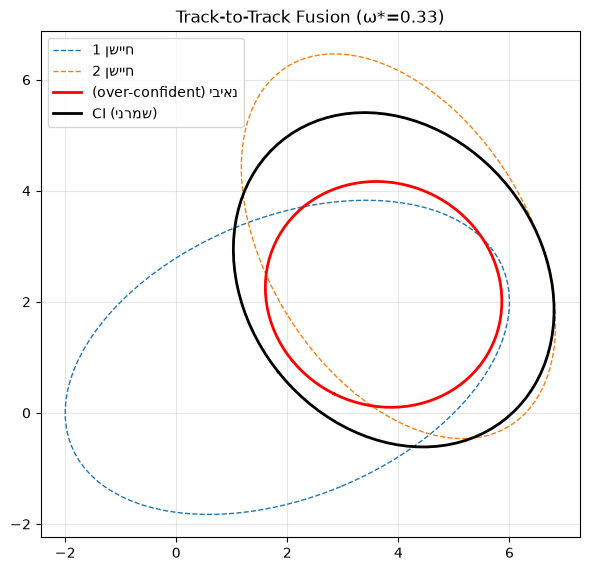

In [4]:
# השוואה ויזואלית של אליפסות: נאיבי קטן מדי, CI שמרני
x1=np.array([2.,1.]); x2=np.array([4.,3.]); P1=np.array([[4,1.],[1,2]]); P2=np.array([[2,-1.],[-1,3]])
xn,Pn=fuse_information([(x1,P1),(x2,P2)]); xci,Pci,w=covariance_intersection(x1,P1,x2,P2)
def ell(P,m,**k):
    th=np.linspace(0,2*np.pi,100); v,Q=np.linalg.eigh(P)
    e=Q@np.diag(2*np.sqrt(v))@np.array([np.cos(th),np.sin(th)]); return e[0]+m[0],e[1]+m[1]
plt.figure(figsize=(6,6))
for P,m,st,lab in [(P1,x1,'C0--','חיישן 1'),(P2,x2,'C1--','חיישן 2'),
                   (Pn,xn,'r-','נאיבי (over-confident)'),(Pci,xci,'k-','CI (שמרני)')]:
    ex,ey=ell(P,m); plt.plot(ex,ey,st,lw=2 if st in('r-','k-') else 1,label=lab)
plt.gca().set_aspect('equal'); plt.legend(); plt.grid(alpha=.3)
plt.title(f'Track-to-Track Fusion (ω*={w:.2f})'); plt.tight_layout(); plt.show()

## סיכום
* **מסנן המידע** הופך היתוך לחיבור — בסיס להיתוך מבוזר; חיישנים בלתי-תלויים: $Y_F=\sum Y_i$.
* **קורלציה נסתרת** בין מסלולים גורמת להיתוך נאיבי להיות over-confident (לא עקבי).
* **Covariance Intersection** מבטיח עקביות לכל קורלציה לא-ידועה — מחיר: אומד שמרני יותר.
* נושאים נוספים בהרצאה: distributed/decentralized Kalman, accumulated state densities, רשתות חיישנים.